In [1]:
from langgraph.graph import StateGraph,START,END
from utils.state import AgentState
from nodes.LoadDataset import Load_file
from nodes.DataProfiling import profile_dataframe
from nodes.PriorityGenerator_a import Priority_generator_a
from nodes.PriorityGenerator_b import Priority_generator_b
from nodes.PriorityGenerator_c import Priority_generator_c
from nodes.DataCleaningAgent import Clean_data,cleaning_tools_node,pop_executed_node_a,pop_executed_node_b,pop_executed_node_c
from nodes.EDA import perform_eda
from nodes.DataAnalysisAgent import Data_analysis,analysis_tools_node
from nodes.DataVisualizationAgent import Data_visualization,visualization_tools_node
from nodes.ChatAgent import chat_node,route_chat,rag_tool_node
from langgraph.prebuilt import tools_condition
from pathlib import Path, WindowsPath
import pandas as pd

In [2]:
graph=StateGraph(AgentState)
    
graph.add_node('LoadFile_node',Load_file)
graph.add_node('DataProfiling_node',profile_dataframe)
graph.add_node('PriorityGenerator1_node',Priority_generator_a)
graph.add_node('DataCleaning_node',Clean_data)
graph.add_node('cleaning_tools_node',cleaning_tools_node)
graph.add_node('pop_executed1_node',pop_executed_node_a)
graph.add_node('pop_executed2_node',pop_executed_node_b)
graph.add_node('pop_executed3_node',pop_executed_node_c)
graph.add_node('EDA_node',perform_eda)
graph.add_node('PriorityGenerator2_node',Priority_generator_b)
graph.add_node('DataAnalysis_node',Data_analysis)
graph.add_node('analysis_tools_node',analysis_tools_node)
graph.add_node('Chat_node',chat_node)
graph.add_node('RAG_tool_node',rag_tool_node)
graph.add_node('PriorityGenerator3_node',Priority_generator_c)
graph.add_node('DataVisualization_node',Data_visualization)
graph.add_node('visualization_tools_node',visualization_tools_node)


graph.add_edge(START,'LoadFile_node')
graph.add_edge('LoadFile_node','DataProfiling_node')
graph.add_edge('DataProfiling_node', 'PriorityGenerator1_node')
graph.add_edge('PriorityGenerator1_node','DataCleaning_node')
graph.add_conditional_edges(
    "DataCleaning_node",
    tools_condition,
    {
        "tools": "cleaning_tools_node",
        "__end__": "EDA_node"
    }
)
graph.add_edge('cleaning_tools_node','pop_executed1_node')
graph.add_edge('pop_executed1_node','DataCleaning_node')
graph.add_edge('EDA_node','PriorityGenerator2_node')
graph.add_edge('PriorityGenerator2_node','DataAnalysis_node')
graph.add_conditional_edges(
    "DataAnalysis_node",
    tools_condition,
    {
        "tools": "analysis_tools_node",
        "__end__": "Chat_node"
    }
)
graph.add_edge('analysis_tools_node','pop_executed2_node')
graph.add_edge('pop_executed2_node','DataAnalysis_node')
graph.add_conditional_edges(
    "Chat_node",
    route_chat,
    {
        "Chat_node": "Chat_node",
        "tools": "RAG_tool_node",
        "PriorityGenerator3_node": "PriorityGenerator3_node"
    }
)

graph.add_edge('RAG_tool_node','Chat_node')
graph.add_edge('PriorityGenerator3_node','DataVisualization_node')
graph.add_conditional_edges(
    "DataVisualization_node",
    tools_condition,
    {
        "tools": "visualization_tools_node",
        "__end__": END
    }
)
graph.add_edge('visualization_tools_node','pop_executed3_node')
graph.add_edge('pop_executed3_node','DataVisualization_node')
# graph.add_edge('Query_node',END)


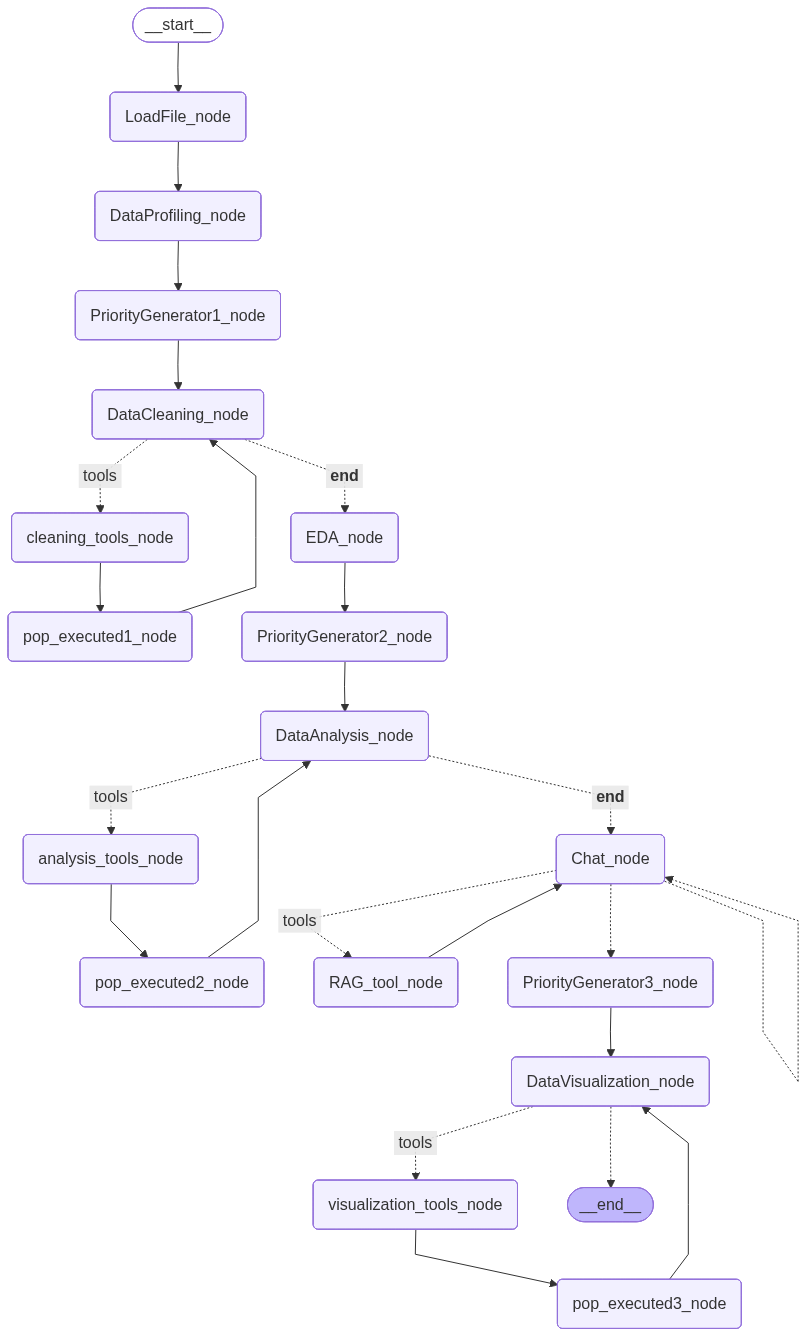

In [3]:
graph.compile()

In [4]:
agent=graph.compile()

In [5]:
initial_state = {"messages":[],"file_path": WindowsPath('uploads/amazon.csv'), "df": None ,"report": {},"tool_priority_list_1" : [],"tool_priority_list_2" : [],"tool_priority_list_3" : [], "clean_df": None, "eda_result": {}, "eda_summary" : {},"analysis_results": {}}
        
final_state = agent.invoke(initial_state)

(1465, 16)


INFO:google_genai.models:AFC is enabled with max remote calls: 10.
INFO:httpx:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite-preview:generateContent "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite-preview:generateContent "HTTP/1.1 200 OK"


[discounted_price]  object → float64  (forced numeric)
[actual_price]  object → float64  (forced numeric)
[discount_percentage]  object → int64  (forced numeric)
[rating]  object → float64  (forced numeric)
[rating_count]  object → float64  (forced numeric)
[product_id]  object → float64  (auto: numeric)
[discounted_price]  float64 → float32  (downcast)
[actual_price]  float64 → float32  (downcast)
[discount_percentage]  int64 → int8  (downcast)
[rating]  float64 → float32  (downcast)
[rating_count]  float64 → float32  (downcast)
[fix_dtypes] Still object dtype after conversion: ['product_name', 'category', 'about_product', 'user_id', 'user_name', 'review_id', 'review_title', 'review_content', 'img_link', 'product_link']


INFO:httpx:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite-preview:generateContent "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite-preview:generateContent "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: POST https://generativelanguage.googleapis.com/v1beta/models/gemini-3.1-flash-lite-preview:generateContent "HTTP/1.1 200 OK"
2026-03-15 09:21:14,690 | INFO     | nodes.EDA | ======================================================================
INFO:nodes.EDA:======================================================================
2026-03-15 09:21:14,691 | INFO     | nodes.EDA | Enterprise EDA pipeline starting...
INFO:nodes.EDA:Enterprise EDA pipeline starting...
2026-03-15 09:21:14,691 | INFO     | nodes.EDA | ======================================================================
INFO:nodes.EDA:======================================================================
20

In [6]:
print(final_state['report'])

{'dataset_overview': {'row_count': 1465, 'column_count': 16, 'duplicate_rows': 0, 'duplicate_rows_pct': 0.0, 'duplicate_columns': [], 'column_name_issues': [], 'dtypes': {'product_id': 'object', 'product_name': 'object', 'category': 'object', 'discounted_price': 'object', 'actual_price': 'object', 'discount_percentage': 'object', 'rating': 'object', 'rating_count': 'object', 'about_product': 'object', 'user_id': 'object', 'user_name': 'object', 'review_id': 'object', 'review_title': 'object', 'review_content': 'object', 'img_link': 'object', 'product_link': 'object'}}, 'completeness_analysis': {'null_counts': {'product_id': 0, 'product_name': 0, 'category': 0, 'discounted_price': 0, 'actual_price': 0, 'discount_percentage': 0, 'rating': 0, 'rating_count': 2, 'about_product': 0, 'user_id': 0, 'user_name': 0, 'review_id': 0, 'review_title': 0, 'review_content': 0, 'img_link': 0, 'product_link': 0}, 'null_pcts': {'product_id': 0.0, 'product_name': 0.0, 'category': 0.0, 'discounted_price':